Wizualizacje metryk równania Poissona, które jest strukturalnie podobne do naszego równania, ale należało dodać nieliniowy współczynnik, użyć Newton Solver, zdefiniować funkcje źródła, przerobić na równanie niestacjonarne, czyli zastosować dyskretyzacje np. metodą eulera, w tym przypadku Euler w tył.

In [2]:
import meshio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv("results/metrics/metrics_stability_m2.csv")

EmptyDataError: No columns to parse from file

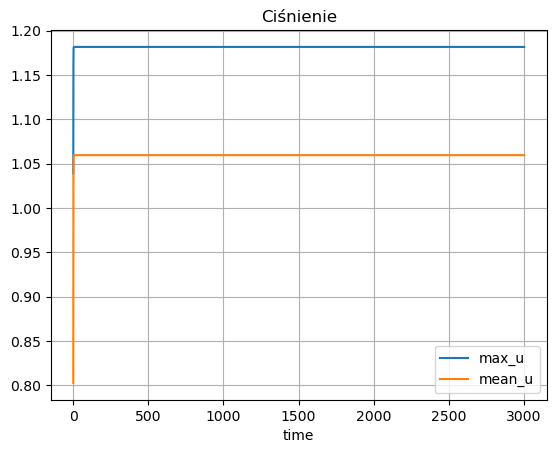

In [53]:
df.plot(x='time', y=['max_u', 'mean_u'], title='Ciśnienie')
plt.grid(True)
plt.show()

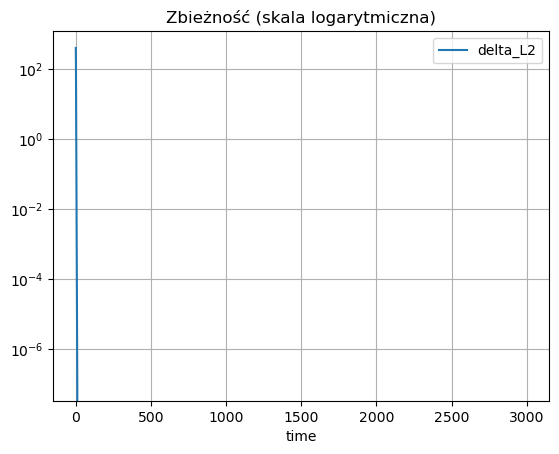

In [54]:
df.plot(x='time', y='delta_L2', logy=True, title='Zbieżność (skala logarytmiczna)')
plt.grid(True)
plt.show()

In [55]:
print(df[['max_u', 'delta_L2']].describe())

             max_u     delta_L2
count  3000.000000  3000.000000
mean      1.181709     0.190302
std       0.002635     7.965381
min       1.038917     0.000000
25%       1.181764     0.000000
50%       1.181764     0.000000
75%       1.181764     0.000000
max       1.181764   412.779408


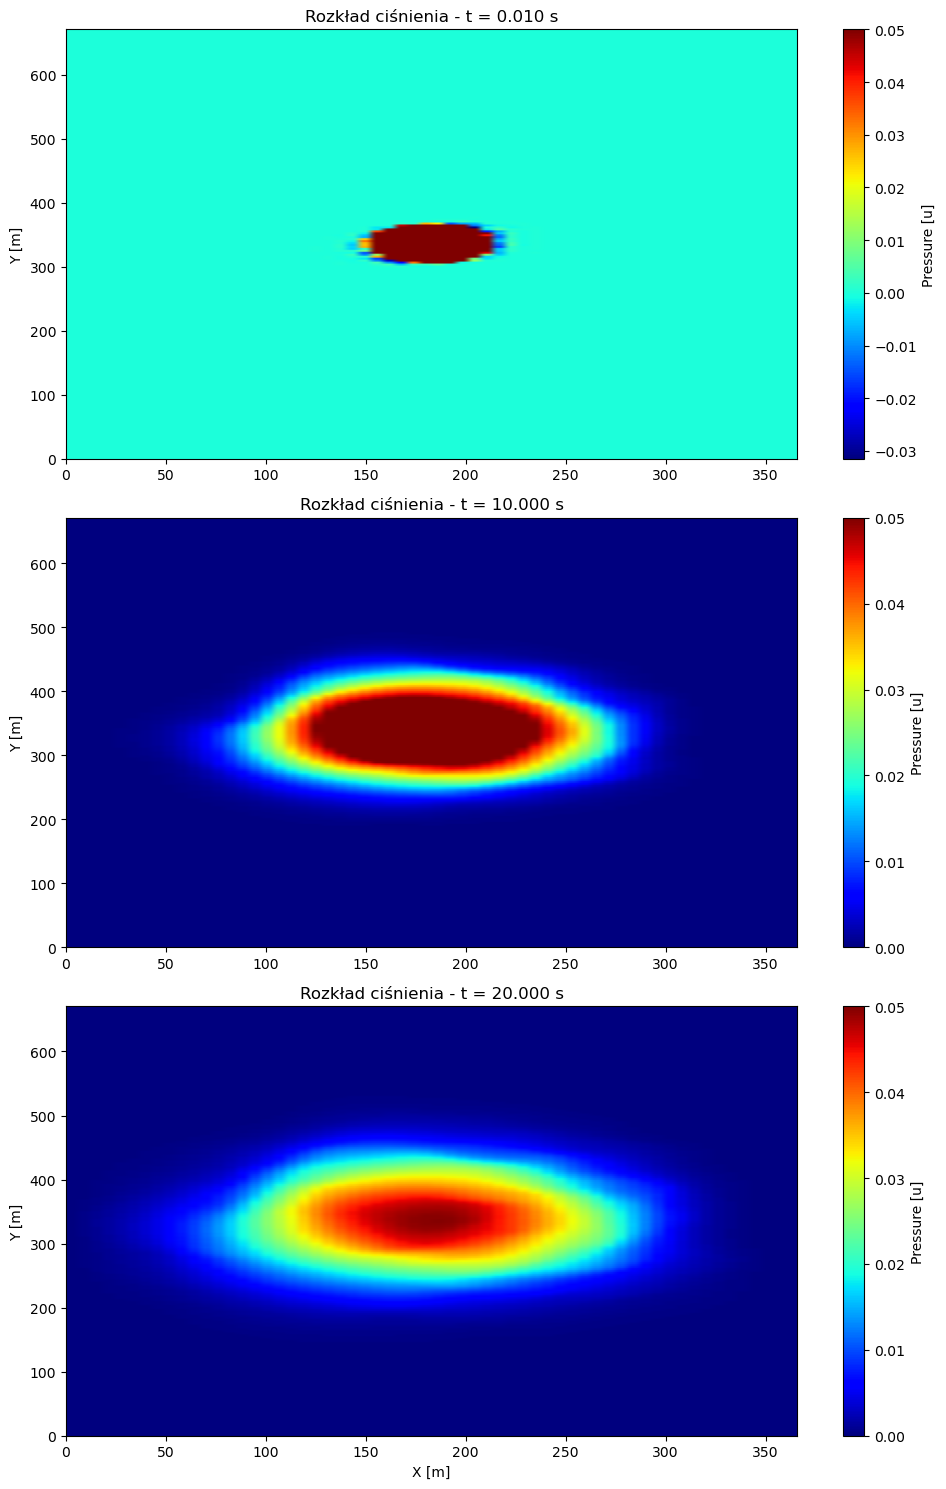

In [ ]:
from scipy.interpolate import griddata

file_path = "/mnt/c/PINN_mgr/FEniCS/eq_newton_spe/results/fields/solution_T20.0_dt0.01.xdmf"
target_times = [0.0, 10.0, 20.0]  # Czas w sekundach, dla którego chcemy zobaczyć rozkład ciśnienia

REAL_NX, REAL_NY = 60, 220
REAL_LX, REAL_LY = 365.76, 670.56

with meshio.xdmf.TimeSeriesReader(file_path) as reader:
    points, _ = reader.read_points_cells()
    
    available_times = np.array([reader.read_data(i)[0] for i in range(reader.num_steps)])

    # Tworzymy regularną siatkę do interpolacji (bitmapę)
    xi = np.linspace(0, REAL_LX, REAL_NX)
    yi = np.linspace(0, REAL_LY, REAL_NY)
    XI, YI = np.meshgrid(xi, yi)

    fig, axes = plt.subplots(len(target_times), 1, figsize=(10, 5 * len(target_times)))
    if len(target_times) == 1: axes = [axes]

    for ax, t_target in zip(axes, target_times):
        idx = (np.abs(available_times - t_target)).argmin()
        t_actual, point_data, _ = reader.read_data(idx)
        u_values = point_data["Pressure"]

        # Kluczowy krok: Interpolacja danych z FEniCS (chmura punktów) na regularną bitmapę
        zi = griddata((points[:, 0], points[:, 1]), u_values, (XI, YI), method='linear')

        # Wyświetlanie jako gładka mapa
        img = ax.imshow(zi, extent=[0, REAL_LX, 0, REAL_LY], 
                        cmap='jet', origin='lower', aspect='auto')
        
        ax.set_title(f"Rozkład ciśnienia - t = {t_actual:.3f} s")
        ax.set_ylabel("Y [m]")
        plt.colorbar(img, ax=ax, label='Pressure [u]')

    axes[-1].set_xlabel("X [m]")
    plt.tight_layout()
    plt.show()

Punkty do porównywania z PINN

In [57]:
import numpy as np
import matplotlib.pyplot as plt

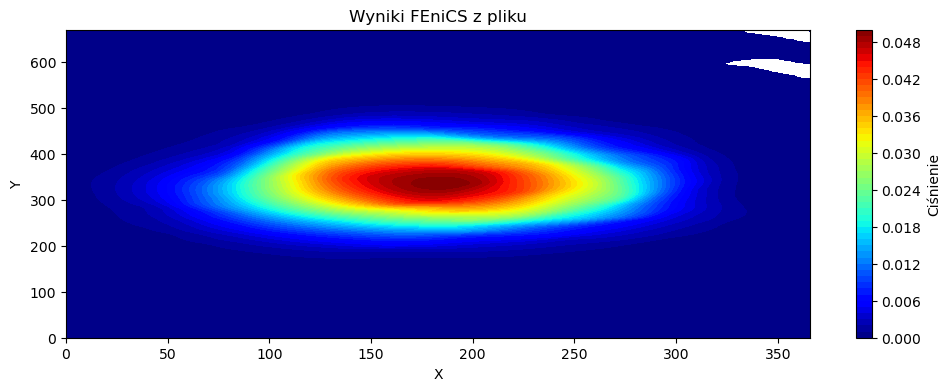

Kształt macierzy u: (220, 60)
Max val u: 0.04965220341203577


In [7]:
data = np.load("results/metrics/fenics_for_pinn_T20.0_dt0.01.npy", allow_pickle=True).item()
x = data['x']
y = data['y']
u = data['u_fenics']

plt.figure(figsize=(12, 4))
contour = plt.contourf(x, y, u, levels=50, cmap='jet')
plt.colorbar(contour, label='Ciśnienie')
plt.title("Wyniki FEniCS z pliku")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

print(f"Kształt macierzy u: {u.shape}")
print(f"Max val u: {np.nanmax(u)}")

In [59]:
row, col = 219,59

print(f"Indeksy: [{row}, {col}]")
print(f"Współrzędne: x = {x[row, col]:.2f}, y = {y[row, col]:.2f}")
print(f"Wartość ciśnienia (u): {u[row, col]:.6f}")

Indeksy: [219, 59]
Współrzędne: x = 365.76, y = 670.56
Wartość ciśnienia (u): -0.000000


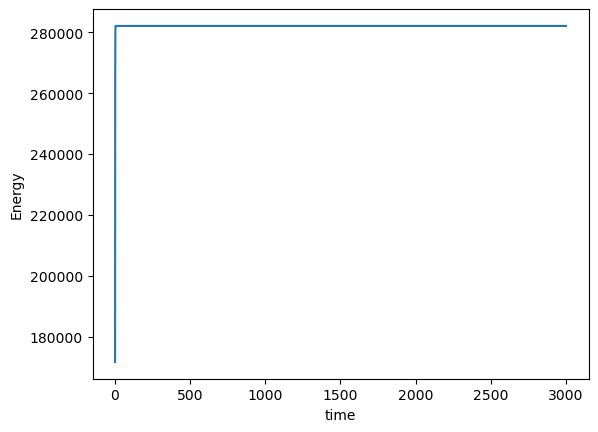

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

data = df

plt.plot(data["time"], data["energy"])
plt.xlabel("time")
plt.ylabel("Energy")
plt.show()